In [ ]:
from sklearn.model_selection import train_test_split
import pandas as pd
import numpy as np

# Create synthetic dataset
data = pd.DataFrame({
    'feature1': np.random.rand(100),
    'feature2': np.random.rand(100),
    'target': np.random.randint(0, 2, 100)
})

X = data[['feature1', 'feature2']]
y = data['target']

# === TRAIN-TEST SPLIT ===
print("=== Splitting Data ===")
X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,    # 20% for testing
    random_state=42   # Reproducibility
)

print(f"Total samples: {len(data)}")
print(f"Training set: {len(X_train)} samples")
print(f"Testing set: {len(X_test)} samples")

# === TRAIN-VALIDATION-TEST SPLIT ===
print("\n=== Train-Validation-Test Split ===")
# First split: Train (80%) + Others (20%)
X_train_full, X_temp, y_train_full, y_temp = train_test_split(X, y, test_size=0.2)
# Second split: Validation (10%) + Test (10%)
X_val, X_test_final, y_val, y_test_final = train_test_split(X_temp, y_temp, test_size=0.5)

print(f"Train: {len(X_train_full)}, Val: {len(X_val)}, Test: {len(X_test_final)}")

=== Splitting Data ===
Total samples: 100
Training set: 80 samples
Testing set: 20 samples

=== Train-Validation-Test Split ===
Train: 80, Val: 10, Test: 10


In [ ]:
import pandas as pd
import numpy as np
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, confusion_matrix
import matplotlib.pyplot as plt

np.random.seed(42)

print("="*70)
print("TRAIN-TEST SPLIT: TOMATO DISEASE CLASSIFICATION")
print("="*70)

# Simulate tomato plant disease data
n_plants = 300

data = pd.DataFrame({
    'Leaf_color_score': np.random.uniform(0, 10, n_plants),
    'Spot_density': np.random.uniform(0, 100, n_plants),
    'Leaf_curl_index': np.random.uniform(0, 5, n_plants),
    'Stem_discoloration': np.random.uniform(0, 10, n_plants),
    'Growth_rate': np.random.uniform(0, 10, n_plants)
})

# Disease classification (0=Healthy, 1=Bacterial, 2=Fungal, 3=Viral)
disease = np.random.choice([0, 1, 2, 3], n_plants, p=[0.5, 0.2, 0.2, 0.1])

print(f"Dataset: {len(data)} tomato plants")
print(f"Features: {list(data.columns)}")
print(f"\nDisease distribution:")
print(f"  Healthy: {sum(disease==0)}")
print(f"  Bacterial: {sum(disease==1)}")
print(f"  Fungal: {sum(disease==2)}")
print(f"  Viral: {sum(disease==3)}")

X = data
y = disease

# Method 1: Simple split
print("\n" + "="*70)
print("METHOD 1: Simple 80-20 Split")
print("="*70)

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

print(f"\nTraining set: {len(X_train)} plants")
print(f"Test set: {len(X_test)} plants")

model = RandomForestClassifier(n_estimators=100, random_state=42)
model.fit(X_train, y_train)

train_acc = model.score(X_train, y_train)
test_acc = model.score(X_test, y_test)

print(f"\nTraining accuracy: {train_acc:.3f}")
print(f"Test accuracy: {test_acc:.3f}")
print(f"Difference: {train_acc - test_acc:.3f}")

if train_acc - test_acc > 0.1:
    print("WARNING: Large gap suggests overfitting!")
else:
    print("Good: Model generalizes well")

# Method 2: Stratified split
print("\n" + "="*70)
print("METHOD 2: Stratified 80-20 Split")
print("="*70)

X_train_s, X_test_s, y_train_s, y_test_s = train_test_split(
    X, y, test_size=0.2, stratify=y, random_state=42
)

print("\nClass distribution comparison:")
print(f"{'Class':<12} {'Original':<12} {'Train':<12} {'Test':<12}")
print("-" * 50)
for cls in range(4):
    orig_pct = sum(y==cls)/len(y)*100
    train_pct = sum(y_train_s==cls)/len(y_train_s)*100
    test_pct = sum(y_test_s==cls)/len(y_test_s)*100
    print(f"{cls:<12} {orig_pct:>6.1f}%{' '*5} {train_pct:>6.1f}%{' '*5} {test_pct:>6.1f}%")

model_s = RandomForestClassifier(n_estimators=100, random_state=42)
model_s.fit(X_train_s, y_train_s)

print(f"\nStratified Test Accuracy: {model_s.score(X_test_s, y_test_s):.3f}")

# Confusion Matrix
y_pred = model_s.predict(X_test_s)
cm = confusion_matrix(y_test_s, y_pred)

print("\nConfusion Matrix:")
print("Predicted ->  H   B   F   V")
print(f"Actual H     {cm[0,0]:3d} {cm[0,1]:3d} {cm[0,2]:3d} {cm[0,3]:3d}")
print(f"       B     {cm[1,0]:3d} {cm[1,1]:3d} {cm[1,2]:3d} {cm[1,3]:3d}")
print(f"       F     {cm[2,0]:3d} {cm[2,1]:3d} {cm[2,2]:3d} {cm[2,3]:3d}")
print(f"       V     {cm[3,0]:3d} {cm[3,1]:3d} {cm[3,2]:3d} {cm[3,3]:3d}")

print("\nKEY TAKEAWAYS:")
print("1. Always split BEFORE training")
print("2. Never use test data for training")
print("3. Use stratified split for imbalanced data")
print("4. Random state ensures reproducibility")

TRAIN-TEST SPLIT: TOMATO DISEASE CLASSIFICATION
Dataset: 300 tomato plants
Features: ['Leaf_color_score', 'Spot_density', 'Leaf_curl_index', 'Stem_discoloration', 'Growth_rate']

Disease distribution:
  Healthy: 152
  Bacterial: 66
  Fungal: 54
  Viral: 28

METHOD 1: Simple 80-20 Split

Training set: 240 plants
Test set: 60 plants

Training accuracy: 1.000
Test accuracy: 0.567
Difference: 0.433

METHOD 2: Stratified 80-20 Split

Class distribution comparison:
Class        Original     Train        Test        
--------------------------------------------------
0              50.7%        50.8%        50.0%
1              22.0%        22.1%        21.7%
2              18.0%        17.9%        18.3%
3               9.3%         9.2%        10.0%

Stratified Test Accuracy: 0.433

Confusion Matrix:
Predicted ->  H   B   F   V
Actual H      24   2   4   0
       B      11   2   0   0
       F       8   3   0   0
       V       5   0   1   0

KEY TAKEAWAYS:
1. Always split BEFORE training
2

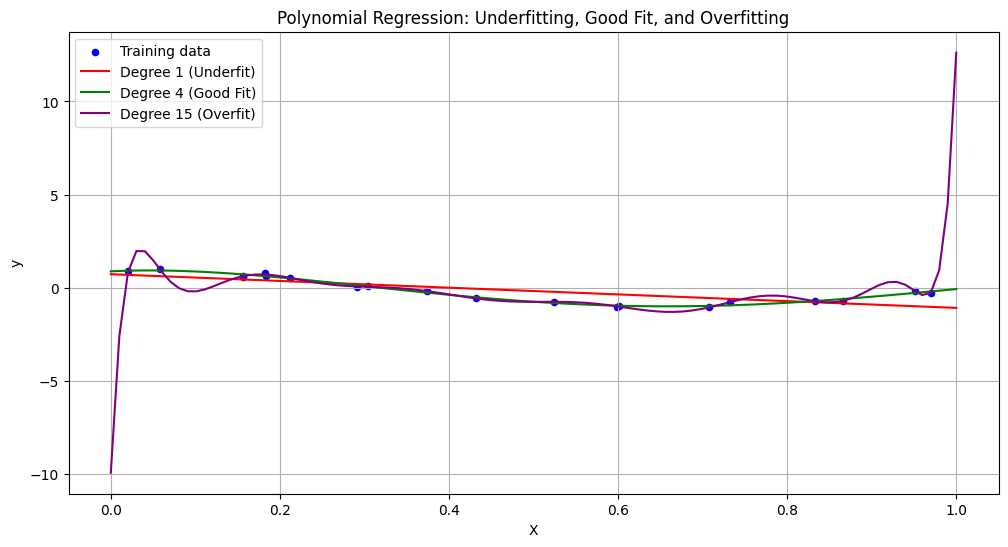

In [ ]:
import numpy as np
import matplotlib.pyplot as plt

# Generate a smoother curve for plotting predictions
X_plot = np.linspace(0, 1, 100)[:, np.newaxis]
y_plot_1 = model1.predict(X_plot)
y_plot_4 = model4.predict(X_plot)
y_plot_15 = model15.predict(X_plot)

plt.figure(figsize=(12, 6))
plt.scatter(X, y, color='blue', s=20, label='Training data')
plt.plot(X_plot, y_plot_1, color='red', label='Degree 1 (Underfit)')
plt.plot(X_plot, y_plot_4, color='green', label='Degree 4 (Good Fit)')
plt.plot(X_plot, y_plot_15, color='purple', label='Degree 15 (Overfit)')

plt.title('Polynomial Regression: Underfitting, Good Fit, and Overfitting')
plt.xlabel('X')
plt.ylabel('y')
plt.legend()
plt.grid(True)
plt.show()